# SPRINT 1: DATA EXPLORATION AND RESEARCH QUESTIONS

OBJETIVOS:

1. Cargar el dataset: código facilitado
2. Explorar el dataset: código facilitado
3. Normalizar la información: completar código
4. Plantear preguntas de investigación relevantes relacionadas con el aprendizaje no supervisado: completar texto
5. Reflexión final sobre técnicas de reducción de datos: completar texto





In [3]:
# import some libraries
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# seaborn is a layer on top of matplotlib which has additional visualizations -
# just importing it changes the look of the standard matplotlib plots.
# the current version also shows some warnings which we'll disable.
import seaborn as sns
sns.set(style="white", color_codes=True)
import warnings
warnings.filterwarnings("ignore")

# show plots inline
%matplotlib inline

## 1.- Load Data





In [4]:
# get data and show some records

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
# load dataset into Pandas DataFrame
data = pd.read_csv(url, names=['sepal length','sepal width','petal length','petal width','target'])


#data = data.drop('Id', axis=1) # get rid of the Id column - don't need it
data.sample(5)

,sepal length,sepal width,petal length,petal width,target
129,7.2,3.0,5.8,1.6,Iris-virginica
86,6.7,3.1,4.7,1.5,Iris-versicolor
72,6.3,2.5,4.9,1.5,Iris-versicolor
56,6.3,3.3,4.7,1.6,Iris-versicolor
138,6.0,3.0,4.8,1.8,Iris-virginica


## 2a.- Explore Data

In [5]:
# split data into features (X) and labels (y)
X = data.iloc[:,0:4]
y = data.iloc[:,-1]

print("\n Caracteristicas \n")
print(X.sample(5))
print("\n Target \n")
print(y.sample(5))


 Caracteristicas 

     sepal length  sepal width  petal length  petal width
137           6.4          3.1           5.5          1.8
41            4.5          2.3           1.3          0.3
81            5.5          2.4           3.7          1.0
146           6.3          2.5           5.0          1.9
54            6.5          2.8           4.6          1.5

 Target 

4          Iris-setosa
63     Iris-versicolor
20         Iris-setosa
141     Iris-virginica
0          Iris-setosa
Name: target, dtype: object


## 2b.- Visualize Data


In [6]:
data["target"].value_counts()


target
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

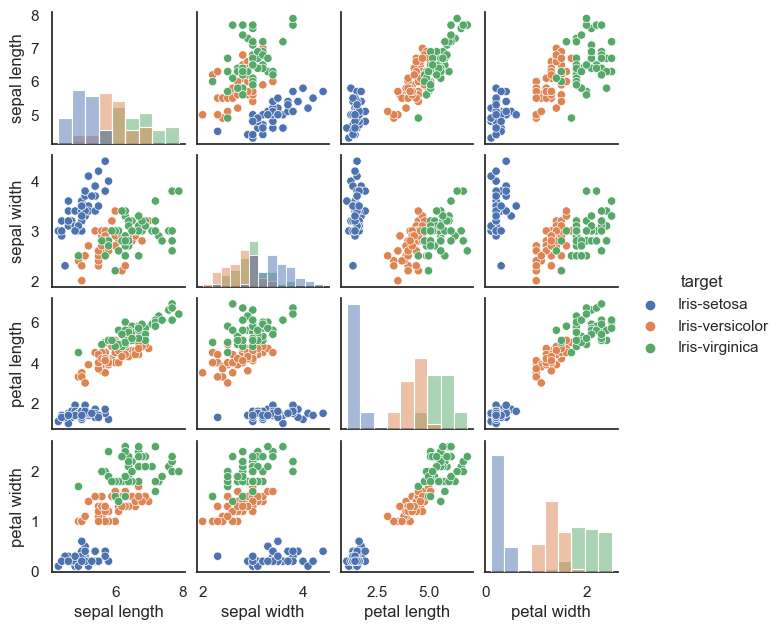

In [ ]:
sns.pairplot(data, hue="target", diag_kind="hist", size=1.6)

Versicolor y Virginica son muy similares, sera muy dificil generar un algoritmo de clustering que las pueda separar, pero vamos a intentarlo!!



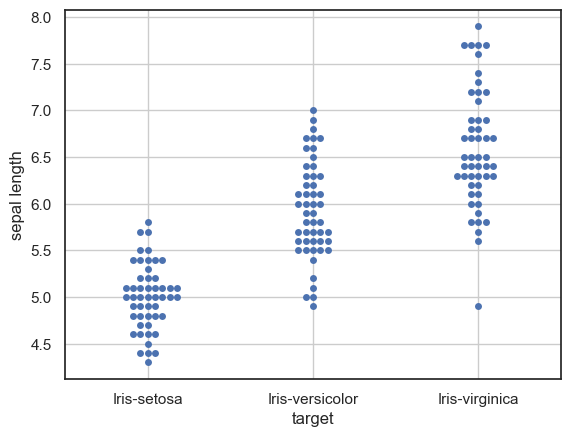

In [8]:
sns.swarmplot(x="target", y="sepal length", data=data)
plt.grid()

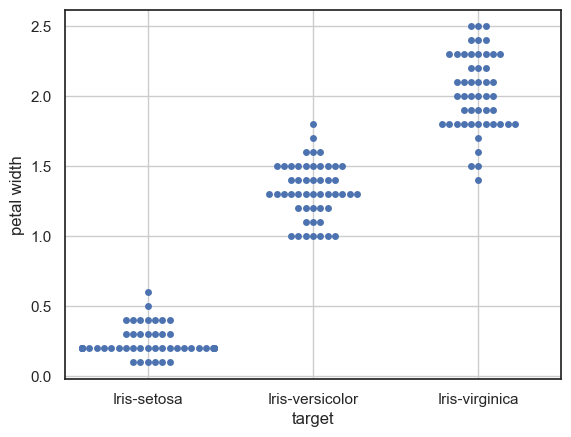

In [9]:
sns.swarmplot(x="target", y="petal width", data=data)
plt.grid()

## 3.- Feature Scaling
Los datos estan desbalanceados por ejemplo Sepal Lenght es aproximadamente 4 veces mas grande que Petal Width, por lo tando recomiendo escalar los valores, de lo contrario, las características más grandes dominarán a las demás en la agrupación, etc.

In [10]:
from sklearn import preprocessing

# Crear un objeto StandardScaler
scaler = preprocessing.StandardScaler()

#INCORPORAR AQUI LAS LINEAS FALTANTES PARA GENERAR UN DATASET CON LAS CARACTERISITCAS ESCALADAS
X_scaled_array = scaler.fit_transform(data[['petal length', 'petal width', 'sepal length', 'sepal width']])

#FIN DE INCORPORAR AQUI LAS LINEAS FALTANTES PARA GENERAR UN DATASET CON LAS CARACTERISITCAS ESCALADAS

X_scaled = pd.DataFrame(X_scaled_array, columns = X.columns)
X_scaled.sample(10)

,sepal length,sepal width,petal length,petal width
49,-1.341272,-1.312977,-1.021849,0.569251
12,-1.341272,-1.444450,-1.264185,-0.124958
69,0.080370,-0.129720,-0.294842,-1.281972
73,0.535296,0.001753,0.310998,-0.587764
97,0.307833,0.133226,0.432165,-0.356361
64,-0.090227,0.133226,-0.294842,-0.356361
61,0.250967,0.396172,0.068662,-0.124958
140,1.047087,1.579429,1.038005,0.106445
149,0.762759,0.790591,0.068662,-0.124958
139,0.933356,1.185010,1.280340,0.106445


##4.- Research questions

--------------------------------------------------------------------
INCORPORA AQUI LAS PREGUNTAS DE INVESTIGACIÓN

--------------------------------------------------------------------
* ¿Qué relación hay entre longitud y anchura de pétalos y sépalos? (Asociación)
* ¿Existe alguna relación entre el tamaño de los sépalos y los pétalos? (Asociación)
* ¿Qué posibles conjuntos podemos agrupar en función de las características de los pétalos y los sépalos? (Agrupación)


## 5.- Reflexión final técnicas de reducción de dimensionalidad

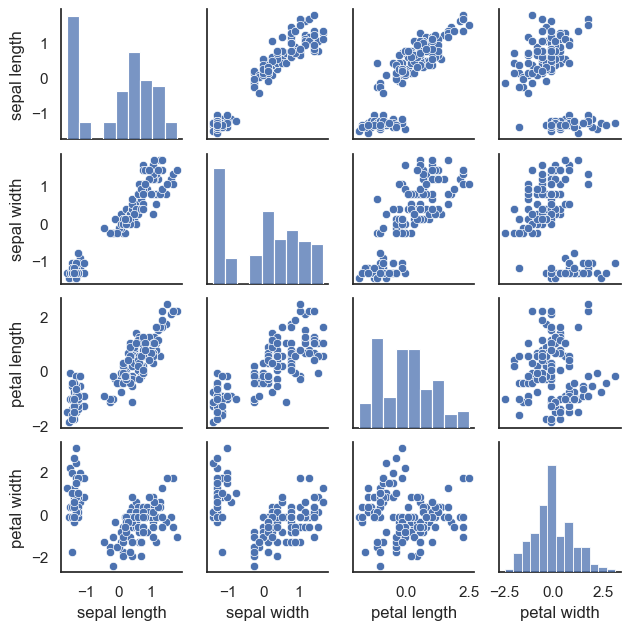

In [12]:
sns.pairplot(X_scaled, diag_kind="hist", size=1.6)

---------------------------------------------------
INCORPORA AQUÍ TU REFLEXIÓN SOBRE ESTE PUNTO
----------------------------------------------------
Si analizamos los datos sin etiquetar tras el reescalado, vemos que algunas relaciones son claramente lineales, como el largo y ancho de los sépalos, u otras que aunque no sea tan claro, sí parecen tener cierta linealidad en su relación, como la longitud del pétalo y del sépalo. Otras, sin embargo, no parecen en absoluto lineales, como el ancho y largo del pétalo. 

Por tanto, para capturar estas relaciones, si pretendemos emplear una reducción de dimensionalidad, deberíamos emplear técnicas diferentes. Por ejemplo, para las relaciones lineales, PCA sería una buena opción, ya que permitiría agrupar dicha información en una menor cantidad de variables; mientras que para las no lineales, otros algoritmos no lineales, tales como t-SNE o UMAP, podrían ser más adecuados, o de lo contrario nos enfrentaríamos a una pérdida sustancial de información.
